# Resource Allocation Log Comparison — Results

Compares two simulated event logs using the evaluation methodology.

**Methodology:** XES logs loaded with pm4py; lifecycle pairing yields durations *d*_i = *t*_complete − *t*_start; non-positive durations discarded. FTE rate κ = 50 €/h. Metrics: cycle time, throughput, handovers, busy hours, C_total = Σ B_r · κ, cost per case, WRF, Gini (G < 0.3 low concentration; 0.3–0.6 moderate; > 0.6 bottleneck risk), termination score S_r with weights α₁=0.25, α₂=0.25, α₃=0.20, α₄=0.15, α₅=0.10, α₆=0.05.

**Logs compared:**
- **Log A:** simulated_log_with_termination
- **Log B:** full_balanced simulated_log

## 1 — Setup & Configuration

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pm4py

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

NOTEBOOK_DIR = Path(os.path.abspath("."))
REPO_ROOT = NOTEBOOK_DIR.parent

COST_PER_FTE_HOUR = 50.0  # κ (€/h)

LOG_A_PATH = REPO_ROOT / "output" / "laste_test_excluded" / "simulated_log.xes"
LOG_A_LABEL = "simulated_log_with_termination"

LOG_B_PATH = REPO_ROOT  / "outpu" / "last_test_full" / "simulated_log.xes"
LOG_B_LABEL = "full_balanced simulated_log"

if not LOG_A_PATH.exists():
    raise FileNotFoundError(f"Log A not found: {LOG_A_PATH}")
if not LOG_B_PATH.exists():
    raise FileNotFoundError(f"Log B not found: {LOG_B_PATH}")

print(f"Log A: {LOG_A_PATH} ({LOG_A_LABEL})")
print(f"Log B: {LOG_B_PATH} ({LOG_B_LABEL})")

Log A: d:\Repos\process-simulation-engine-1\output\laste_test_excluded\simulated_log.xes (simulated_log_with_termination)
Log B: d:\Repos\process-simulation-engine-1\outpu\last_test_full\simulated_log.xes (full_balanced simulated_log)


## 2 — Load & Validate Both Logs

In [2]:
REQUIRED_COLS = {"case:concept:name", "concept:name", "time:timestamp"}


def load_log(path: Path) -> pd.DataFrame:
    if str(path).endswith(".csv"):
        df = pd.read_csv(path)
    else:
        log = pm4py.read_xes(str(path))
        df = pm4py.convert_to_dataframe(log)
    df.columns = [c.lower() for c in df.columns]
    rename_map = {
        "case:concept:name": "case:concept:name",
        "concept:name": "concept:name",
        "time:timestamp": "time:timestamp",
        "org:resource": "org:resource",
        "lifecycle:transition": "lifecycle:transition",
    }
    df = df.rename(columns={c.lower(): c for c in rename_map})
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], utc=True, format="ISO8601")
    return df


def filter_start_complete(df: pd.DataFrame) -> pd.DataFrame:
    if "lifecycle:transition" not in df.columns:
        return df
    mask = df["lifecycle:transition"].astype(str).str.lower().isin(["start", "complete"])
    return df[mask].copy()


def describe_log(df: pd.DataFrame, label: str) -> None:
    n_cases = df["case:concept:name"].nunique()
    n_events = len(df)
    has_resource = "org:resource" in df.columns
    has_lifecycle = "lifecycle:transition" in df.columns
    print(f"[{label}] Cases: {n_cases:,} | Events: {n_events:,} | Resource: {'✓' if has_resource else '✗'} | Lifecycle: {'✓' if has_lifecycle else '✗'}")


df_a = load_log(LOG_A_PATH)
df_b = load_log(LOG_B_PATH)

describe_log(df_a, LOG_A_LABEL)
describe_log(df_b, LOG_B_LABEL)

[simulated_log_with_termination] Cases: 10 | Events: 262 | Resource: ✓ | Lifecycle: ✓
[full_balanced simulated_log] Cases: 10 | Events: 303 | Resource: ✓ | Lifecycle: ✓


## Results — Side-by-Side Comparison

## 3 — Metric Computation Functions

In [3]:
def extract_activity_durations(df: pd.DataFrame) -> tuple[pd.DataFrame, bool]:
    has_lifecycle = "lifecycle:transition" in df.columns
    if not has_lifecycle:
        return pd.DataFrame(), False

    df_sorted = df.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)
    lc = df_sorted["lifecycle:transition"].str.lower()
    starts = df_sorted[lc == "start"].copy()
    completes = df_sorted[lc == "complete"].copy()
    if completes.empty:
        return pd.DataFrame(), False

    merge_cols = ["case:concept:name", "concept:name"]
    if "org:resource" in df.columns:
        merge_cols.append("org:resource")
    activities_with_start = set(starts["concept:name"].unique())

    for _df in [starts, completes]:
        _df["_occ"] = _df.groupby(merge_cols).cumcount()
    full_starts = starts[starts["concept:name"].isin(activities_with_start)]
    full_completes = completes[completes["concept:name"].isin(activities_with_start)]

    df_full = pd.DataFrame()
    if not full_starts.empty and not full_completes.empty:
        df_full = pd.merge(
            full_starts.rename(columns={"time:timestamp": "start_time"})[merge_cols + ["_occ", "start_time"]],
            full_completes.rename(columns={"time:timestamp": "complete_time"})[merge_cols + ["_occ", "complete_time"]],
            on=merge_cols + ["_occ"], how="inner",
        )
        df_full["duration_hours"] = (df_full["complete_time"] - df_full["start_time"]).dt.total_seconds() / 3600
        df_full = df_full.drop(columns=["_occ"])

    complete_only = completes[~completes["concept:name"].isin(activities_with_start)]
    df_comp_only = pd.DataFrame()
    if not complete_only.empty:
        df_sorted["_prev_time"] = df_sorted.groupby("case:concept:name")["time:timestamp"].shift(1)
        comp_rows = df_sorted.loc[(lc == "complete") & (~df_sorted["concept:name"].isin(activities_with_start))].copy()
        comp_rows = comp_rows[comp_rows["_prev_time"].notna()]
        if not comp_rows.empty:
            comp_rows["duration_hours"] = (comp_rows["time:timestamp"] - comp_rows["_prev_time"]).dt.total_seconds() / 3600
            comp_rows = comp_rows.rename(columns={"time:timestamp": "complete_time"})
            comp_rows["start_time"] = comp_rows["_prev_time"]
            out_cols = merge_cols + ["start_time", "complete_time", "duration_hours"]
            df_comp_only = comp_rows[out_cols].copy()

    df_dur = pd.concat([df_full, df_comp_only], ignore_index=True)
    df_dur = df_dur[df_dur["duration_hours"] > 0].reset_index(drop=True)
    return df_dur, not df_dur.empty


def compute_case_metrics(df: pd.DataFrame) -> pd.DataFrame:
    grp = df.sort_values("time:timestamp").groupby("case:concept:name")
    case_start = grp["time:timestamp"].min().rename("case_start")
    case_end = grp["time:timestamp"].max().rename("case_end")
    n_events = grp.size().rename("n_events")
    df_cases = pd.concat([case_start, case_end, n_events], axis=1)
    df_cases["cycle_time_days"] = (df_cases["case_end"] - df_cases["case_start"]).dt.total_seconds() / 86_400
    if "org:resource" in df.columns:
        def count_handovers(sub):
            r = sub.sort_values("time:timestamp")["org:resource"].dropna().tolist()
            return sum(1 for a, b in zip(r, r[1:]) if a != b)
        df_cases["handovers"] = grp.apply(count_handovers)
    else:
        df_cases["handovers"] = np.nan
    return df_cases.reset_index()


def compute_resource_metrics(df_durations: pd.DataFrame, has_durations: bool) -> pd.DataFrame | None:
    if not has_durations or "org:resource" not in df_durations.columns:
        return None
    df_res = (
        df_durations.groupby("org:resource")["duration_hours"]
        .sum()
        .reset_index()
        .rename(columns={"org:resource": "resource", "duration_hours": "busy_hours"})
        .sort_values("busy_hours", ascending=False)
        .reset_index(drop=True)
    )
    df_res["work_share"] = df_res["busy_hours"] / df_res["busy_hours"].sum()
    return df_res


def compute_all_metrics(df_raw: pd.DataFrame, cost_per_fte: float) -> dict:
    df_dur, has_dur = extract_activity_durations(df_raw)
    df_cases = compute_case_metrics(df_raw)
    df_res = compute_resource_metrics(df_dur, has_dur)

    total_busy = float(df_res["busy_hours"].sum()) if df_res is not None else np.nan
    fte_cost = total_busy * cost_per_fte if not np.isnan(total_busy) else np.nan
    n = len(df_cases)

    def safe_mean(s):
        return float(s.mean()) if s.notna().any() else np.nan

    rm = compute_resource_features(df_raw, df_dur, df_cases, has_dur, cost_per_fte)
    max_term, mean_term = np.nan, np.nan
    if rm is not None and len(rm) > 0:
        for col, norm in [("fte_cost", "norm_cost"), ("productivity", "norm_productivity"), ("contribution_per_cost", "norm_value"),
                          ("distinct_cases_count", "norm_contribution"), ("workload_share", "norm_workload_share"), ("cycle_time_delta", "norm_cycle_delta")]:
            rm[norm] = percentile_normalize(rm[col])
        rm["termination_score"] = (
            W_COST * rm["norm_cost"]
            + W_LOW_PRODUCTIVITY * (1 - rm["norm_productivity"])
            + W_LOW_VALUE * (1 - rm["norm_value"])
            + W_LOW_CONTRIBUTION * (1 - rm["norm_contribution"])
            + W_CRITICALITY * (1 - rm["norm_workload_share"])
            + W_CYCLE_IMPACT * rm["norm_cycle_delta"]
        )
        max_term = float(rm["termination_score"].max())
        mean_term = float(rm["termination_score"].mean())

    return {
        "Avg Cycle Time (days)": float(df_cases["cycle_time_days"].mean()),
        "Median Cycle Time (days)": float(df_cases["cycle_time_days"].median()),
        "Range Cycle Time (days)": float(df_cases["cycle_time_days"].max() - df_cases["cycle_time_days"].min()),
        "Throughput (cases/day)": n / ((df_cases["case_end"].max() - df_cases["case_start"].min()).total_seconds() / 86400) if n > 0 else np.nan,
        "Avg Resource Occupation (share)": float(df_res["work_share"].mean()) if df_res is not None else np.nan,
        "Weighted Resource Fairness": _wrf(df_res) if df_res is not None else np.nan,
        "Workload Gini Coefficient": gini_coefficient(df_res["busy_hours"].values) if df_res is not None else np.nan,
        "Total Busy Hours": total_busy,
        "Total FTE Cost (€)": fte_cost,
        "Cost per Completed Case (€)": fte_cost / n if n > 0 and not np.isnan(fte_cost) else np.nan,
        "Avg Handovers per Case": safe_mean(df_cases["handovers"]),
        "Number of Resources": len(df_res) if df_res is not None else np.nan,
        "Max Termination Score": max_term,
        "Mean Termination Score": mean_term,
    }


def _wrf(df_res: pd.DataFrame) -> float:
    shares = df_res["work_share"].values
    weights = df_res["busy_hours"].values / df_res["busy_hours"].sum()
    return float(np.sum(weights * np.abs(shares - shares.mean())))


def gini_coefficient(values: np.ndarray) -> float:
    v = np.sort(np.asarray(values, dtype=float))
    v = v[v >= 0]
    n = len(v)
    if n == 0 or v.sum() == 0:
        return np.nan
    ranks = np.arange(1, n + 1)
    return float((2 * (ranks * v).sum()) / (n * v.sum()) - (n + 1) / n)


def compute_resource_features(df_raw, df_durations, df_cases, has_durations, cost_per_fte):
    if "org:resource" not in df_raw.columns or not has_durations:
        return None
    df_complete = df_raw[df_raw["lifecycle:transition"].str.lower() == "complete"].copy() if "lifecycle:transition" in df_raw.columns else df_raw.copy()
    busy = df_durations.groupby("org:resource")["duration_hours"].sum().reset_index().rename(columns={"org:resource": "resource", "duration_hours": "busy_hours"})
    busy["fte_cost"] = busy["busy_hours"] * cost_per_fte
    busy["workload_share"] = busy["busy_hours"] / busy["busy_hours"].sum()
    event_counts = df_complete.groupby("org:resource").size().reset_index(name="completed_events_count").rename(columns={"org:resource": "resource"})
    case_counts = df_complete.groupby("org:resource")["case:concept:name"].nunique().reset_index().rename(columns={"org:resource": "resource", "case:concept:name": "distinct_cases_count"})
    case_ct = df_cases[["case:concept:name", "cycle_time_days"]].copy()
    resource_cases = df_complete[["org:resource", "case:concept:name"]].drop_duplicates().rename(columns={"org:resource": "resource"})
    resource_ct = resource_cases.merge(case_ct, on="case:concept:name", how="left").groupby("resource")["cycle_time_days"].mean().reset_index().rename(columns={"cycle_time_days": "avg_cycle_time_of_cases_involved"})
    global_avg_ct = df_cases["cycle_time_days"].mean()
    rm = busy.merge(event_counts, on="resource", how="left").merge(case_counts, on="resource", how="left").merge(resource_ct, on="resource", how="left")
    rm["productivity"] = rm["completed_events_count"] / rm["busy_hours"]
    rm["contribution_per_cost"] = rm["distinct_cases_count"] / rm["fte_cost"]
    rm["cycle_time_delta"] = rm["avg_cycle_time_of_cases_involved"] - global_avg_ct
    return rm


def percentile_normalize(series: pd.Series, p_low: float = 5, p_high: float = 95) -> pd.Series:
    lo, hi = np.percentile(series.dropna(), p_low), np.percentile(series.dropna(), p_high)
    clipped = series.clip(lower=lo, upper=hi)
    return pd.Series(0.5, index=series.index) if (hi - lo) == 0 else (clipped - lo) / (hi - lo)


# Termination score weights: α₁=0.25, α₂=0.25, α₃=0.20, α₄=0.15, α₅=0.10, α₆=0.05
W_COST, W_LOW_PRODUCTIVITY, W_LOW_VALUE = 0.25, 0.25, 0.20
W_LOW_CONTRIBUTION, W_CRITICALITY, W_CYCLE_IMPACT = 0.15, 0.10, 0.05

## 5 — Distribution of changes (many runs)

Run multiple paired simulations (with vs without terminated resources) to get a **distribution** of metric changes:

```bash
python -m integration.run_termination_comparison --n-runs 10 --exclude-resources User_128,User_129 --output-csv evaluation/termination_comparison_runs.csv
```

Load the CSV below to view summary statistics and histograms of the differences.

Distribution of difference (without − with termination) across runs:


,Avg Cycle Time (days),Median Cycle Time (days),Range Cycle Time (days),Throughput (cases/day),Avg Resource Occupation (share),Weighted Resource Fairness,Workload Gini Coefficient,Total Busy Hours,Total FTE Cost (€),Cost per Completed Case (€),Avg Handovers per Case,Number of Resources,Max Termination Score,Mean Termination Score
mean,4.2533,-3.8690,41.5927,-0.0692,-0.0003,0.1620,0.1892,826.9659,41348.2937,413.4829,4.3090,1.5000,-0.0049,-0.0033
std,8.3932,1.4608,90.0507,0.1629,0.0003,0.0317,0.0425,3782.4803,189124.0168,1891.2402,8.5526,1.7014,0.0243,0.0361
min,-8.9211,-6.2090,-60.7762,-0.6804,-0.0010,0.1144,0.1054,-5072.7188,-253635.9394,-2536.3594,-8.0100,-1.0000,-0.0506,-0.0811
max,24.0212,-1.4016,290.4666,0.0438,0.0002,0.2200,0.2668,7511.9476,375597.3816,3755.9738,25.4600,5.0000,0.0418,0.0519
median,5.1033,-3.8693,10.9538,-0.0114,-0.0002,0.1605,0.1888,125.8658,6293.2881,62.9329,4.8350,1.0000,-0.0055,0.0005


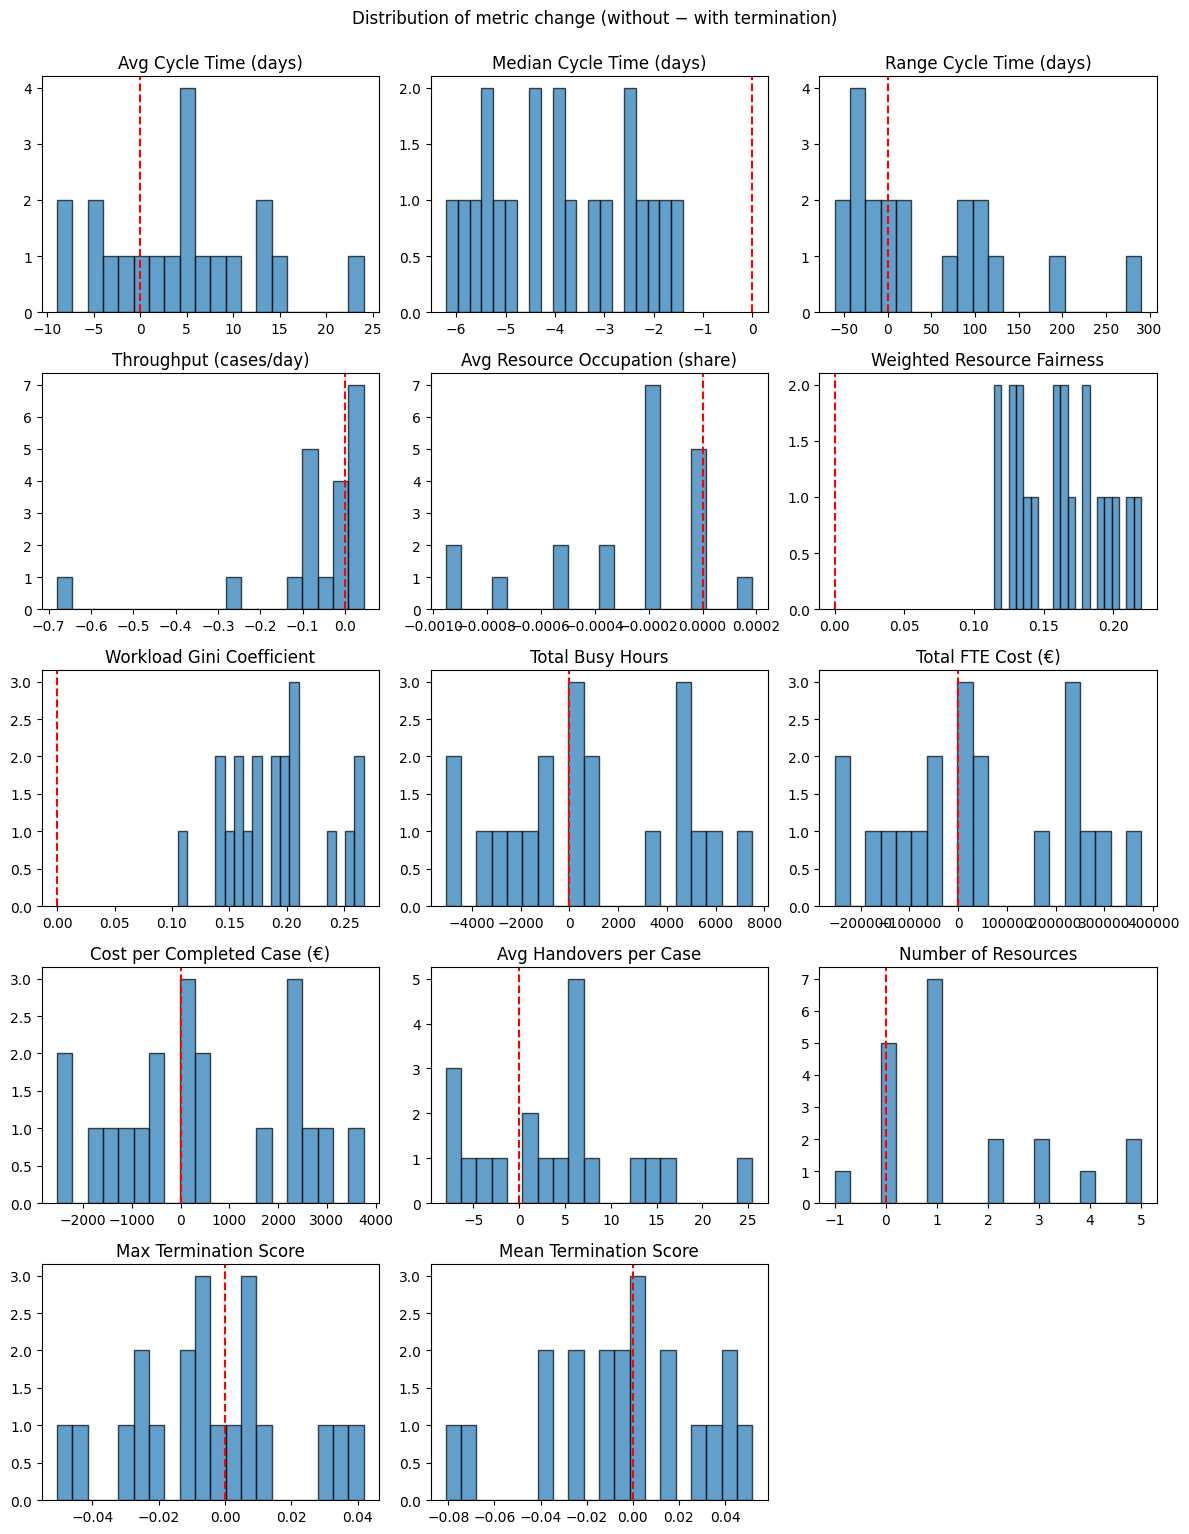

In [ ]:
import matplotlib.pyplot as plt

RUNS_CSV = REPO_ROOT / "evaluation" / "termination_comparison_runs.csv"

if RUNS_CSV.exists():
    df_runs = pd.read_csv(RUNS_CSV)
    diff_cols = [c for c in df_runs.columns if c.endswith("_diff")]
    metric_names = [c.replace("_diff", "") for c in diff_cols]

    summary = df_runs[diff_cols].agg(["mean", "std", "min", "max", "median"])
    summary.columns = metric_names
    summary.index = ["mean", "std", "min", "max", "median"]
    print("Distribution of difference (without − with termination) across runs:")
    display(summary.round(4))

    n_metrics = len(metric_names)
    n_cols = 3
    n_rows = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for i, name in enumerate(metric_names):
        values = df_runs[f"{name}_diff"].dropna().values
        if len(values) == 0:
            axes[i].set_visible(False)
            continue
        bins = min(20, max(5, len(values)))
        axes[i].hist(values, bins=bins, density=True, edgecolor="black", alpha=0.7)
        mu = float(values.mean())
        sigma = float(values.std(ddof=0)) if len(values) > 1 else 0.0
        if sigma > 0:
            xs = np.linspace(values.min(), values.max(), 200)
            pdf = 1.0 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
            axes[i].plot(xs, pdf, color="red", linestyle="-", linewidth=1.5)
        axes[i].set_title(name[:40] + ("..." if len(name) > 40 else ""))
        axes[i].axvline(0, color="black", linestyle="--", linewidth=1)
    for j in range(len(metric_names), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.suptitle("Distribution of metric change (without − with termination)", y=1.02)
    plt.show()
else:
    print(f"Runs CSV not found: {RUNS_CSV}")
    print("Run: python -m integration.run_termination_comparison --n-runs 10 --exclude-resources User_128,User_129")

## 4 — Side-by-Side Comparison

In [4]:
metrics_a = compute_all_metrics(df_a, COST_PER_FTE_HOUR)
metrics_b = compute_all_metrics(df_b, COST_PER_FTE_HOUR)

comparison = pd.DataFrame({
    LOG_A_LABEL: metrics_a,
    LOG_B_LABEL: metrics_b,
})
comparison["Difference (B - A)"] = comparison[LOG_B_LABEL] - comparison[LOG_A_LABEL]

def pct_change(a, b):
    if np.isnan(a) or np.isnan(b) or a == 0:
        return np.nan
    return (b - a) / a * 100

comparison["% Change"] = [pct_change(metrics_a[k], metrics_b[k]) for k in comparison.index]

comparison.round(4)

,simulated_log_with_termination,full_balanced simulated_log,Difference (B - A),% Change
Avg Cycle Time (days),11.0445,13.3813,2.3369,21.1589
Median Cycle Time (days),10.7776,12.3518,1.5743,14.6067
Range Cycle Time (days),12.6328,17.3497,4.7169,37.3387
Throughput (cases/day),0.5908,0.3893,-0.2015,-34.1023
Avg Resource Occupation (share),0.0294,0.0294,-0.0000,-0.0000
Weighted Resource Fairness,0.0458,0.0939,0.0481,105.0727
Workload Gini Coefficient,0.5250,0.5698,0.0448,8.5308
Total Busy Hours,449.7462,757.0272,307.2811,68.3232
Total FTE Cost (€),22487.3076,37851.3605,15364.0528,68.3232
Cost per Completed Case (€),2248.7308,3785.1360,1536.4053,68.3232
